In [23]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

In [24]:
import os
print(os.getcwd())
print(os.listdir("."))

C:\Projects\ML Safety Sose 26\data
['.ipynb_checkpoints', 'best_model.pth', 'calibration', 'dataset.py', 'Excercise 5', 'Exercise_7 (1).ipynb', 'exercise_sheet_7.ipynb', 'explainability', 'ml-es3.ipynb', 'pedestrian_model.pth', 'requirements.txt', 'test', 'test-fog', 'test-night', 'test-town-01', 'traffic_light_model.pth', 'train', 'train_model.py', 'validation', 'vehicle_model.pth', 'venv', '__pycache__']


In [25]:
train_dir = "train/rgb-front"
train_labels = "train/labels.csv"

id_dir = "test/rgb-front"
id_labels = "test/labels.csv"

fog_dir = "test-fog/rgb-front"
fog_labels = "test-fog/labels.csv"

night_dir = "test-night/rgb-front"
night_labels = "night_data/test-night/labels.csv"

town_dir = "test-town-01/rgb-front"
town_labels = "test-town-01/labels.csv"

In [37]:
print(os.listdir("test"))
print(os.listdir("test-fog"))
print(os.listdir("test-night"))
print(os.listdir("test-town-01"))

['.hydra', 'actions.feather', 'carla.log', 'collisions.feather', 'gnss.feather', 'imu.feather', 'labels.csv', 'labels.feather', 'rgb-front', 'segmentation-front', 'sim.log', 'weather.feather']
['.hydra', 'actions.feather', 'carla.log', 'collisions.feather', 'gnss.feather', 'imu.feather', 'labels.csv', 'labels.feather', 'rgb-front', 'segmentation-front', 'sim.log', 'weather.feather']
['.hydra', 'actions.feather', 'carla.log', 'collisions.feather', 'gnss.feather', 'imu.feather', 'labels.csv', 'labels.feather', 'rgb-front', 'segmentation-front', 'sim.log', 'weather.feather']
['.hydra', 'actions.feather', 'carla.log', 'collisions.feather', 'gnss.feather', 'imu.feather', 'labels.csv', 'labels.feather', 'rgb-front', 'segmentation-front', 'sim.log', 'weather.feather']


In [38]:
import os

id_folder = "test/rgb-front"
fog_folder = "test-fog/rgb-front"
night_folder = "test-night/rgb-front"
town_folder = "test-town-01/rgb-front"

print(os.path.exists(id_folder))
print(os.path.exists(fog_folder))
print(os.path.exists(night_folder))
print(os.path.exists(town_folder))

True
True
True
True


In [26]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [27]:
def get_samples(folder, n=5):
    files = sorted(os.listdir(folder))[:n]
    return [os.path.join(folder, f) for f in files]

In [28]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def load_images(folder, n=5):
    files = sorted(os.listdir(folder))[:n]
    images = []
    for f in files:
        path = os.path.join(folder, f)
        try:
            img = Image.open(path).convert("RGB")
            images.append(img)
        except Exception as e:
            print("Error:", path, e)
    return images

In [29]:
id_imgs = load_images(id_dir, 5)
fog_imgs = load_images(fog_dir, 5)
night_imgs = load_images(night_dir, 5)
town_imgs = load_images(town_dir, 5)

This shows 5 images per domain clearly

In [30]:
def plot_images(images, title):
    plt.figure(figsize=(15, 3))
    plt.suptitle(title)

    for i, img in enumerate(images):
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

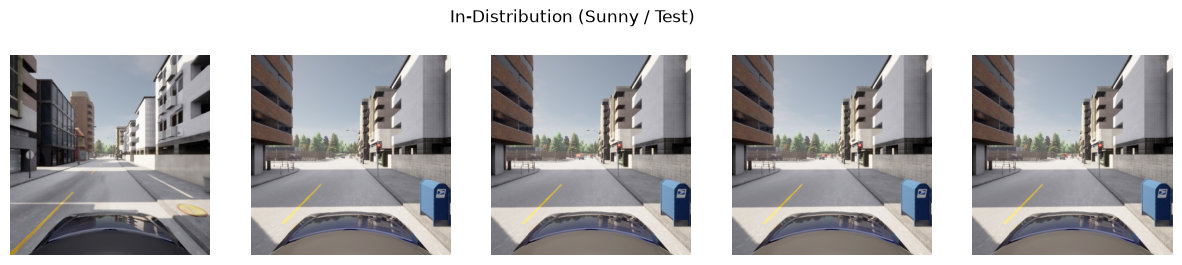

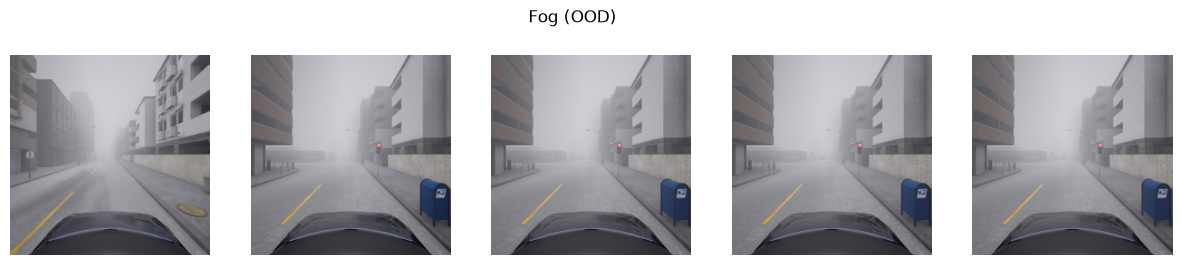

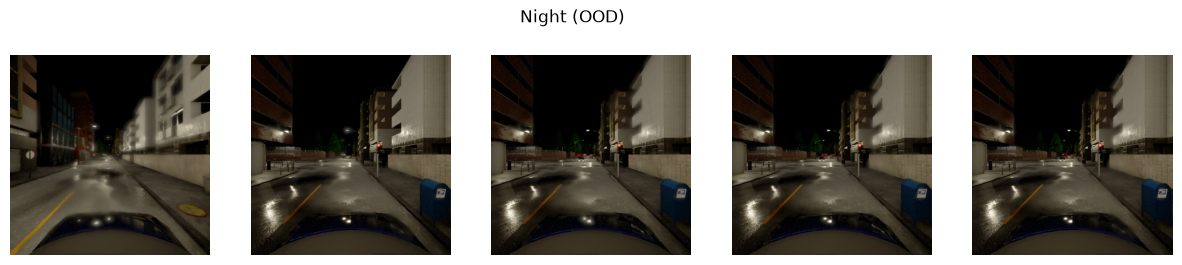

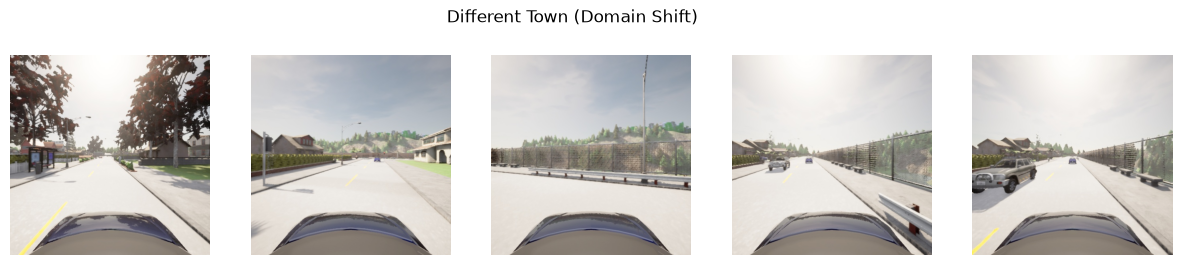

In [31]:
plot_images(id_imgs, "In-Distribution (Sunny / Test)")
plot_images(fog_imgs, "Fog (OOD)")
plot_images(night_imgs, "Night (OOD)")
plot_images(town_imgs, "Different Town (Domain Shift)")


In [32]:
def mean_confidence_ped(model, folder):
    confidences = []

    model.eval()
    model.to(device)

    with torch.no_grad():
        for img_name in sorted(os.listdir(folder)):

            if not img_name.endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(folder, img_name)

            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            output = model(img)

            prob = torch.sigmoid(output).item()
            confidence = max(prob, 1 - prob)

            confidences.append(confidence)

    return sum(confidences) / len(confidences)

In [33]:
id_folder = "data/test/rgb-front"
fog_folder = "fog_data/test-fog/rgb-front"
night_folder = "night_data/test-night/rgb-front"

In [34]:
import torch
from torchvision import models
import torch.nn as nn

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

ped_model = models.resnet18(pretrained=False)
ped_model.fc = nn.Linear(ped_model.fc.in_features, 1)

ped_model.load_state_dict(torch.load("pedestrian_model.pth", map_location=device))

ped_model = ped_model.to(device)
ped_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [39]:
print("Pedestrian Model")
print("ID:", mean_confidence_ped(ped_model, id_folder))
print("Fog:", mean_confidence_ped(ped_model, fog_folder))
print("Night:", mean_confidence_ped(ped_model, night_folder))
print("Town:", mean_confidence_ped(ped_model, town_folder))

Pedestrian Model
ID: 0.9454607458358814
Fog: 0.9761373336729594
Night: 0.9760953645159316
Town: 0.9579340463340218


In [41]:
import torch
print(torch.cuda.is_available())

True


In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [43]:
import torch
from torchvision.models import resnet18

checkpoint = torch.load("vehicle_model.pth", map_location=device)
vehicle_model = resnet18(pretrained=False)
vehicle_model.fc = torch.nn.Linear(vehicle_model.fc.in_features, 1)
vehicle_model.load_state_dict(checkpoint)
vehicle_model = vehicle_model.to(device)
vehicle_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [44]:
from PIL import Image
import os

# pick ONE image from fog folder (you can change folder later)
img_name = os.listdir(fog_folder)[0]

img_path = os.path.join(fog_folder, img_name)

img = Image.open(img_path).convert("RGB")

img = transform(img).unsqueeze(0).to(device)

In [45]:
output = vehicle_model(img)
print(output)

tensor([[-0.7522]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [46]:
def mean_confidence(model, folder):
    confidences = []

    model.eval()
    model.to(device)

    with torch.no_grad():
        for img_name in sorted(os.listdir(folder)):

            if not img_name.endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(folder, img_name)

            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            output = model(img)

            prob = torch.sigmoid(output).item()
            confidence = max(prob, 1 - prob)

            confidences.append(confidence)

    return sum(confidences) / len(confidences)

In [47]:
print("Vehicle Model")
print("ID:", mean_confidence(vehicle_model, id_folder))
print("Fog:", mean_confidence(vehicle_model, fog_folder))
print("Night:", mean_confidence(vehicle_model, night_folder))

Vehicle Model
ID: 0.9042102387238993
Fog: 0.6094093421246443
Night: 0.8616225067981416


In [48]:
from torchvision.models import resnet18
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

traffic_model = resnet18(pretrained=False)
traffic_model.fc = nn.Linear(traffic_model.fc.in_features, 1)

traffic_model.load_state_dict(torch.load("traffic_light_model.pth", map_location=device))

traffic_model = traffic_model.to(device)
traffic_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [49]:
def mean_confidence_traffic(model, folder):
    confidences = []

    model.eval()
    model.to(device)

    with torch.no_grad():
        for img_name in sorted(os.listdir(folder)):

            if not img_name.endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(folder, img_name)

            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            output = model(img)

            prob = torch.sigmoid(output).item()
            confidence = max(prob, 1 - prob)

            confidences.append(confidence)

    return sum(confidences) / len(confidences)

In [50]:
print("Traffic Light Model")
print("ID:", mean_confidence_traffic(traffic_model, id_folder))
print("Fog:", mean_confidence_traffic(traffic_model, fog_folder))
print("Night:", mean_confidence_traffic(traffic_model, night_folder))

Traffic Light Model
ID: 0.9627643755352356
Fog: 0.8137890151815534
Night: 0.9998955531534107


# 9.4.2

The different-town images have similar weather and lighting conditions to the training data but contain different road layouts, buildings, and vegetation. In contrast, fog and night images introduce significant appearance changes due to reduced visibility and lighting conditions. Therefore, fog and night represent an appearance shift, while the different town represents a structural or domain shift.

# 9.4.3

The confidence values remain high for both in-distribution and OOD images. Some models show reduced confidence under fog conditions, while others remain highly confident even on night images. This suggests that the models are often overconfident on OOD inputs and that confidence alone may not reliably indicate distribution shift.


# 9.5.1

The original ODD does not explicitly mention whether a new unseen town is included. It only defines environmental conditions like weather, lighting, and road type, but not geographical variation.

# 9.5.2

The system operates in daytime, clear-weather urban environments with standard traffic conditions, clean camera input, and moderate vehicle speeds. This includes different urban layouts (different towns) as long as environmental conditions remain similar to training data.

# 9.5.3

The system operates in daytime, clear-weather urban environments with standard traffic conditions, clean camera input, and moderate vehicle speeds. This includes different urban layouts (different towns) as long as environmental conditions remain similar to training data.

# 9.6

In [51]:
def get_msp(model, folder):
    scores = []

    model.eval()
    model.to(device)

    with torch.no_grad():
        for img_name in sorted(os.listdir(folder)):

            if not img_name.endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(folder, img_name)

            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            output = model(img)

            prob = torch.sigmoid(output)
            msp = max(prob.item(), 1 - prob.item())

            scores.append(msp)

    return np.array(scores)

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vehicle_model = vehicle_model.to(device)
vehicle_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [53]:
id_scores = get_msp(vehicle_model, id_folder)
fog_scores = get_msp(vehicle_model, fog_folder)
night_scores = get_msp(vehicle_model, night_folder)
town_scores = get_msp(vehicle_model, town_dir)

ood_scores = np.concatenate([fog_scores, night_scores, town_scores])

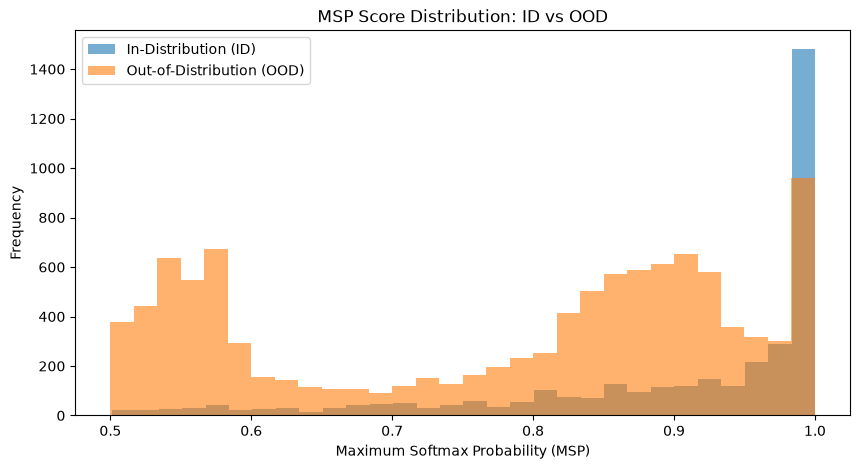

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(id_scores, bins=30, alpha=0.6, label="In-Distribution (ID)")
plt.hist(ood_scores, bins=30, alpha=0.6, label="Out-of-Distribution (OOD)")

plt.title("MSP Score Distribution: ID vs OOD")
plt.xlabel("Maximum Softmax Probability (MSP)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

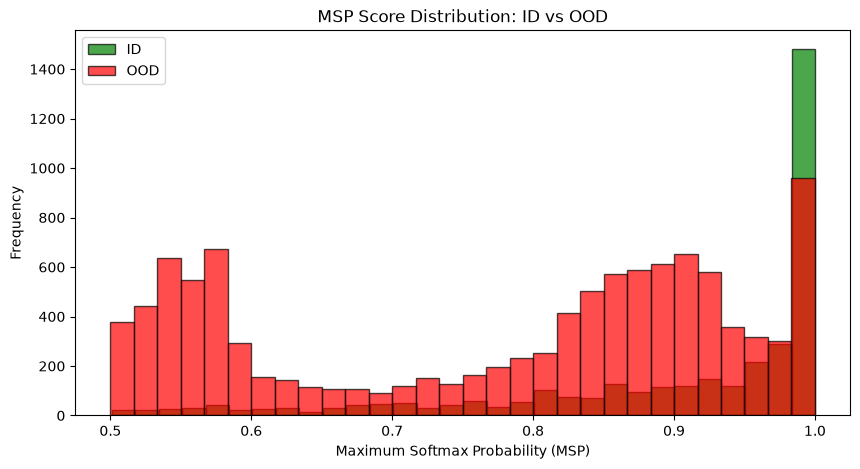

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(id_scores, bins=30, alpha=0.7, label="ID", color="green", edgecolor="black")
plt.hist(ood_scores, bins=30, alpha=0.7, label="OOD", color="red", edgecolor="black")

plt.title("MSP Score Distribution: ID vs OOD")
plt.xlabel("Maximum Softmax Probability (MSP)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

np.concatenate()- Combines multiple arrays into a single array along a specified axis.
np.ones()-Creates an array filled with ones of a given size.
roc_auc_score()-Computes the AUROC score, measuring how well a model separates two classes using prediction scores.

In [56]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true = np.concatenate([
    np.ones(len(id_scores)),   # ID = 1
    np.zeros(len(ood_scores))  # OOD = 0
])

y_scores = np.concatenate([
    id_scores,
    ood_scores
])

auroc = roc_auc_score(y_true, y_scores)

print("AUROC:", auroc)

AUROC: 0.7513901491769548


# 9.7

In [60]:
import torch
import numpy as np
from torchvision.models import resnet18
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score
from PIL import Image
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from torchvision.models import resnet18

model = resnet18(weights=None)
model.fc = torch.nn.Identity()   # feature extractor

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [61]:
import torch
import numpy as np
from torchvision.models import resnet18
from PIL import Image
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet18(weights=None)
model.fc = torch.nn.Identity()

model = model.to(device)
model.eval()

def extract_features(model, folder):
    features = []

    with torch.no_grad():
        for img_name in sorted(os.listdir(folder)):

            if not img_name.endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(folder, img_name)

            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            feat = model(img)
            features.append(feat.cpu().numpy().flatten())

    return np.array(features)

In [62]:
id_feat = extract_features(model, id_folder)
fog_feat = extract_features(model, fog_folder)
night_feat = extract_features(model, night_folder)
town_feat = extract_features(model, town_dir)

ood_feat = np.concatenate([fog_feat, night_feat, town_feat])

In [63]:
knn = NearestNeighbors(n_neighbors=5)
knn.fit(id_feat)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'eu...an'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [64]:
def knn_score(model_knn, features):
    distances, _ = model_knn.kneighbors(features)
    return distances.mean(axis=1)   # larger distance = more OOD

In [65]:
id_scores_knn = knn_score(knn, id_feat)
ood_scores_knn = knn_score(knn, ood_feat)

In [66]:
y_true = np.concatenate([
    np.ones(len(id_scores_knn)),   # ID = 1
    np.zeros(len(ood_scores_knn))  # OOD = 0
])

y_scores = np.concatenate([
    id_scores_knn,
    ood_scores_knn
])


y_scores = -y_scores

auroc_knn = roc_auc_score(y_true, y_scores)

print("k-NN AUROC:", auroc_knn)

k-NN AUROC: 0.9826736625514404


In [67]:
print("MSP AUROC (from before):", auroc)
print("k-NN AUROC:", auroc_knn)

MSP AUROC (from before): 0.7513901491769548
k-NN AUROC: 0.9826736625514404


Feature-based OOD detection uses distances in deep representation space instead of prediction confidence, making it more reliable than MSP for detecting distribution shifts.